In [1]:
import pandas as pd
import numpy as np


In [15]:


import pandas as pd

df = pd.DataFrame({

    "Income":[
        5,7,8,10,12,15,18,20,22,25,
        28,30,35,40,45,50,55,60,70,80,
        90,100,110,120,130,150,170,200,220,250,
        300,350,400,450,500,600,700,800,900,1000
    ],

    "LoanAmount":[
        20,22,25,28,30,35,38,40,45,48,
        50,55,60,65,70,80,90,100,120,130,
        150,170,180,200,220,250,270,300,320,350,
        400,450,500,550,600,650,700,800,900,1000
    ],

    "Savings":[
        1,2,3,4,5,6,7,8,9,10,
        12,14,16,18,20,22,25,28,30,35,
        40,45,50,60,70,80,90,100,120,140,
        160,180,200,250,300,350,400,500,700,900
    ],

    "Experience":[
        1,2,2,3,3,4,4,5,5,6,
        6,7,7,8,8,9,9,10,10,11,
        11,12,12,13,13,14,14,15,15,16,
        16,17,17,18,18,19,20,21,22,25
    ],

    "LoanApproved":[
        0,0,0,0,0,0,0,0,0,0,
        0,0,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1
    ]
})

df.to_csv("loan_data.csv",index=False)

In [16]:
df.head()

,Income,LoanAmount,Savings,Experience,LoanApproved
0,5,20,1,1,0
1,7,22,2,2,0
2,8,25,3,2,0
3,10,28,4,3,0
4,12,30,5,3,0


In [8]:
#1]box-cox transformation
#used when data is positive(>0)
#0 and -ve value not allowed in box-cox transformation
# if is there any zero and -ve value its give error

In [10]:
#1]box-cox transformation

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

In [17]:
df.isnull().sum()

Income          0
LoanAmount      0
Savings         0
Experience      0
LoanApproved    0
dtype: int64

In [18]:
df.describe()

,Income,LoanAmount,Savings,Experience,LoanApproved
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,204.375000,252.775000,125.250000,11.200000,0.700000
std,265.418556,267.468329,198.348663,6.223199,0.464095
min,5.000000,20.000000,1.000000,1.000000,0.000000
25%,27.250000,49.500000,11.500000,6.000000,0.000000
50%,85.000000,140.000000,37.500000,11.000000,1.000000
75%,262.500000,362.500000,145.000000,16.000000,1.000000
max,1000.000000,1000.000000,900.000000,25.000000,1.000000


In [20]:
# to check data is skewed or not

df.skew()

Income          1.696434
LoanAmount      1.322812
Savings         2.479946
Experience      0.215850
LoanApproved   -0.907254
dtype: float64

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

In [24]:
df.head(5)

,Income,LoanAmount,Savings,Experience,LoanApproved
0,5,20,1,1,0
1,7,22,2,2,0
2,8,25,3,2,0
3,10,28,4,3,0
4,12,30,5,3,0


In [34]:
x=df.drop(columns=["LoanApproved"])
y=df[["LoanApproved"]]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [53]:
x_train

,Income,LoanAmount,Savings,Experience
13,40,65,18,8
31,350,450,180,17
34,500,600,300,18
8,22,45,9,5
17,60,100,28,10
24,130,220,70,13
0,5,20,1,1
33,450,550,250,18
5,15,35,6,4
11,30,55,14,7


In [36]:
x_train.shape

(28, 4)

In [37]:
y_train.shape

(28, 1)

In [39]:
x_test.shape

(12, 4)

In [41]:
y_test.shape

(12, 1)

In [45]:
pt=PowerTransformer(method="box-cox")

x_train_pt=pt.fit_transform(x_train)
x_test_pt=pt.transform(x_test)



In [51]:
x_train_pt_df=pd.DataFrame(x_train_pt,columns=x_train.columns)

In [49]:
# x_train_pt

In [50]:
import matplotlib.pyplot as plt
from scipy import stats

Text(0.5, 1.0, 'After Box-Cox Transformation')

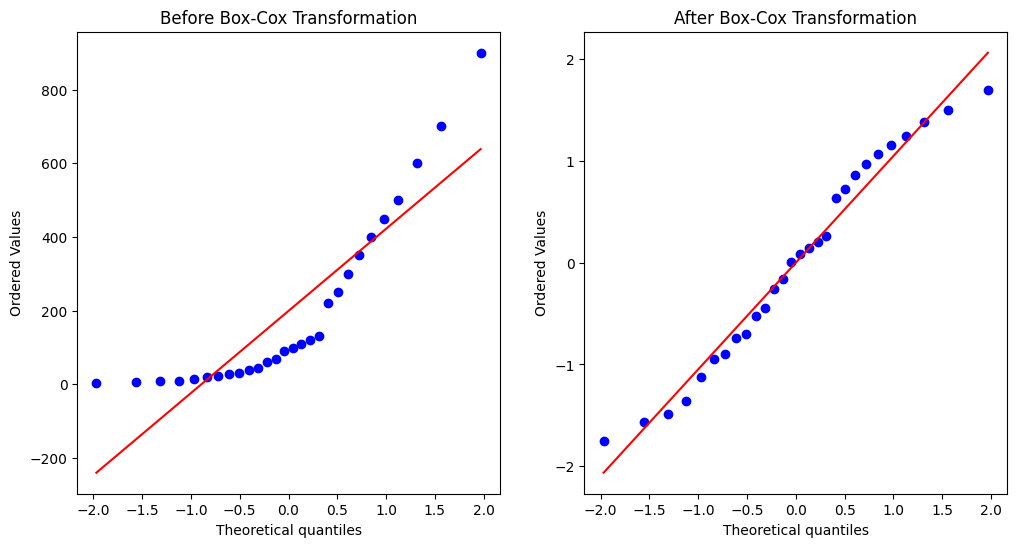

In [54]:
#DISTRIBUTION FOR INCOME

fig,ax=plt.subplots(1,2,figsize=(12,6))

stats.probplot(x_train["Income"],dist="norm",plot=ax[0])
ax[0].set_title("Before Box-Cox Transformation")

stats.probplot(x_train_pt_df["Income"],dist="norm",plot=ax[1])
ax[1].set_title("After Box-Cox Transformation")

In [56]:
x_train.head(1)

,Income,LoanAmount,Savings,Experience
13,40,65,18,8


Text(0.5, 1.0, 'After Box-Cox Transformation')

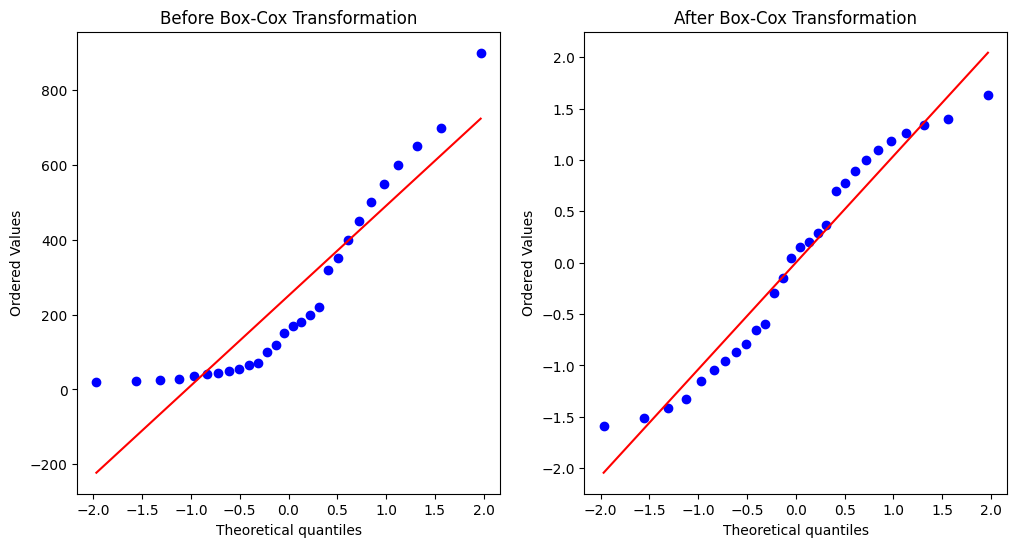

In [57]:
#DISTRIBUTION FOR LOAN AMOUNT

fig,ax=plt.subplots(1,2,figsize=(12,6))
stats.probplot(x_train["LoanAmount"],dist="norm",plot=ax[0])
ax[0].set_title("Before Box-Cox Transformation")
stats.probplot(x_train_pt_df["LoanAmount"],dist="norm",plot=ax[1])
ax[1].set_title("After Box-Cox Transformation")

Text(0.5, 1.0, 'After Box-Cox Transformation')

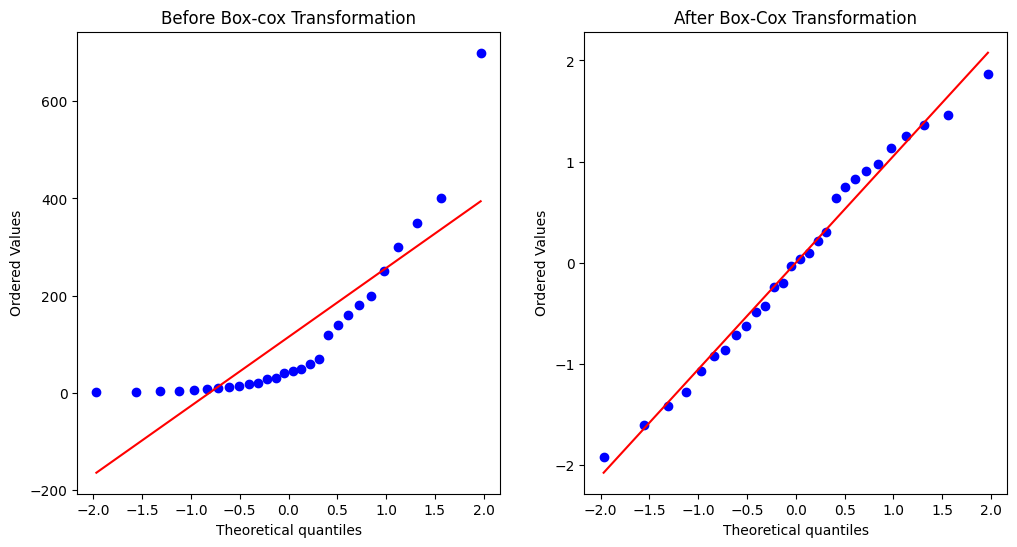

In [59]:
#DISTRIBUTION FOR Savings

fig,ax=plt.subplots(1,2,figsize=(12,6))

stats.probplot(x_train["Savings"],dist="norm",plot=ax[0])
ax[0].set_title("Before Box-cox Transformation")

stats.probplot(x_train_pt_df["Savings"],dist="norm",plot=ax[1])
ax[1].set_title("After Box-Cox Transformation")

In [61]:
x_train.head(1)

,Income,LoanAmount,Savings,Experience
13,40,65,18,8


Text(0.5, 1.0, 'After Box-Cox Transformation')

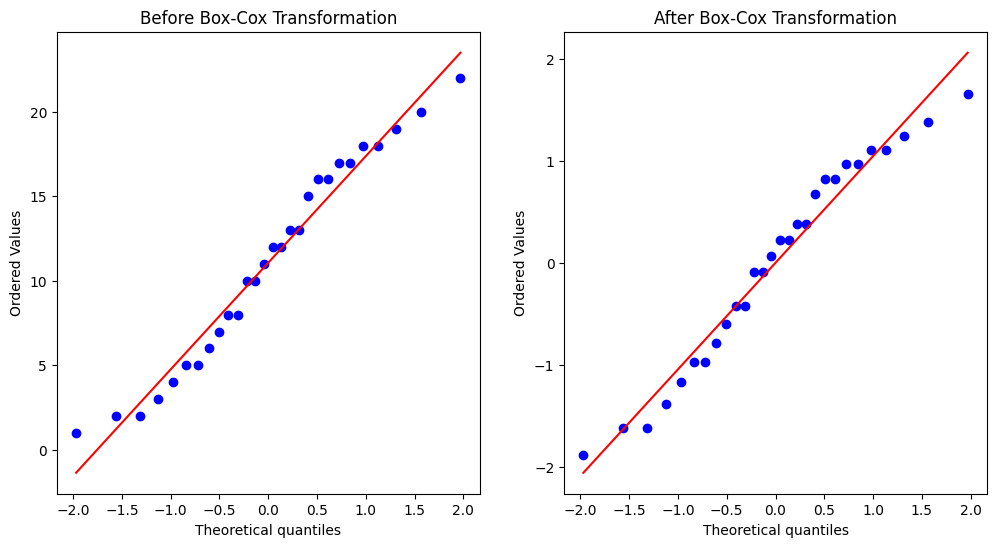

In [63]:
#DISTRIBUTION FOR EXPERIENCE

fig,ax=plt.subplots(1,2,figsize=(12,6))

stats.probplot(x_train["Experience"],dist="norm",plot=ax[0])
ax[0].set_title("Before Box-Cox Transformation")

stats.probplot(x_train_pt_df["Experience"],dist="norm",plot=ax[1])
ax[1].set_title("After Box-Cox Transformation")

In [73]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import  LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr=LogisticRegression()
lr2=LogisticRegression()

lr.fit(x_train,y_train)
lr2.fit(x_train_pt,y_train)

y_pred_lr=lr.predict(x_test)
y_pred_lr2=lr2.predict(x_test_pt)

print("Accuracy of Logistic Regression without Box-Cox Transformation:",accuracy_score(y_test,y_pred_lr))
print("Accuracy of Logistic Regression with Box-Cox Transformation:",accuracy_score(y_test,y_pred_lr2))

Accuracy of Logistic Regression without Box-Cox Transformation: 0.9166666666666666
Accuracy of Logistic Regression with Box-Cox Transformation: 0.9166666666666666


c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [75]:
lr=DecisionTreeClassifier()
lr2=DecisionTreeClassifier()

lr.fit(x_train,y_train)
lr2.fit(x_train_pt,y_train)

y_pred_lr=lr.predict(x_test)
y_pred_lr2=lr2.predict(x_test_pt)

print("Accuracy of Decision Tree without Box-Cox Transformation:",accuracy_score(y_test,y_pred_lr))
print("Accuracy of Decision Tree with Box-Cox Transformation:",accuracy_score(y_test,y_pred_lr2))

Accuracy of Decision Tree without Box-Cox Transformation: 0.9166666666666666
Accuracy of Decision Tree with Box-Cox Transformation: 1.0


In [77]:
import pandas as pd

df = pd.DataFrame({

    "Area":[
        500,550,600,650,700,750,800,850,900,950,
        1000,1100,1200,1300,1400,1500,1600,1700,1800,1900,
        2000,2200,2400,2600,2800,3000,3500,4000,4500,5000,
        5500,6000,6500,7000,7500,8000,8500,9000,9500,10000
    ],

    "DistanceFromCity":[
        40,38,37,35,34,33,32,30,29,28,
        27,25,24,23,22,21,20,19,18,17,
        16,15,14,13,12,11,10,9,8,7,
        6,5,4,4,3,3,2,2,1,1
    ],

    "Rooms":[
        1,1,1,2,2,2,2,2,3,3,
        3,3,3,4,4,4,4,4,5,5,
        5,5,5,6,6,6,6,7,7,7,
        7,8,8,8,8,9,9,9,10,10
    ],

    "HousePrice":[
        10000,12000,14000,15000,17000,19000,21000,24000,27000,30000,
        35000,40000,45000,50000,55000,62000,68000,74000,80000,87000,
        95000,110000,130000,150000,180000,220000,280000,350000,430000,520000,
        620000,730000,850000,980000,1120000,1270000,1430000,1600000,1780000,2000000
    ]
})

df.to_csv("house_data.csv",index=False)

In [79]:
df.head()

,Area,DistanceFromCity,Rooms,HousePrice
0,500,40,1,10000
1,550,38,1,12000
2,600,37,1,14000
3,650,35,2,15000
4,700,34,2,17000


In [81]:
df.shape

(40, 4)

In [84]:
x = df.drop(columns=["HousePrice"])
y = df[["HousePrice"]]

In [92]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [93]:
x_train.head()

,Area,DistanceFromCity,Rooms
13,1300,23,4
31,6000,5,8
34,7500,3,8
8,900,29,3
17,1700,19,4


In [103]:
x_train.shape

(28, 3)

In [104]:
x_test.shape

(12, 3)

In [101]:
y_train.shape

(28, 1)

In [100]:
y_test.shape

(12, 1)

In [108]:
pt=PowerTransformer(method="box-cox")

x_train_house=pt.fit_transform(x_train)
x_test_house=pt.transform(x_test)

In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [115]:
lr=LinearRegression()
lr2=LinearRegression()

lr.fit(x_train,y_train)
lr2.fit(x_train_house,y_train)

lr.predict(x_test)
y_pred_lr=lr.predict(x_test)
y_pred_lr2=lr2.predict(x_test_house)

print("R2 Score of Linear Regression without Box-Cox Transformation:",r2_score(y_test,y_pred_lr))
print("R2 Score of Linear Regression with Box-Cox Transformation:",r2_score(y_test,y_pred_lr2))


R2 Score of Linear Regression without Box-Cox Transformation: 0.9766057877235269
R2 Score of Linear Regression with Box-Cox Transformation: 0.9408753460896778


In [120]:
x_train_house_df = pd.DataFrame(x_train_house,columns=x_train.columns)

In [116]:
x_train.skew()

Area                0.827979
DistanceFromCity    0.348095
Rooms               0.048178
dtype: float64

In [117]:
"""Area               high skew 😄
DistanceFromCity   moderate skew
Rooms               low skew"""

'Area               high skew 😄\nDistanceFromCity   moderate skew\nRooms               low skew'

Text(0.5, 1.0, 'Rooms After Box-Cox Transformation')

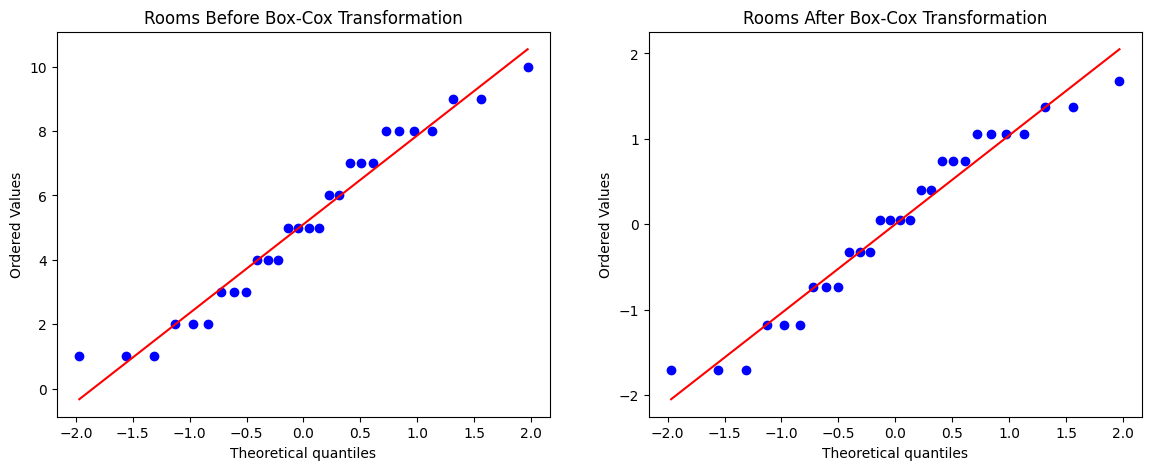

In [121]:
fig,ax=plt.subplots(1,2,figsize=(14,5))

stats.probplot(x_train["Rooms"],dist="norm",plot=ax[0])
ax[0].set_title('Rooms Before Box-Cox Transformation')

stats.probplot(x_train_house_df["Rooms"],dist="norm",plot=ax[1])
ax[1].set_title('Rooms After Box-Cox Transformation')


Text(0.5, 1.0, 'Area After Box-Cox Transformation')

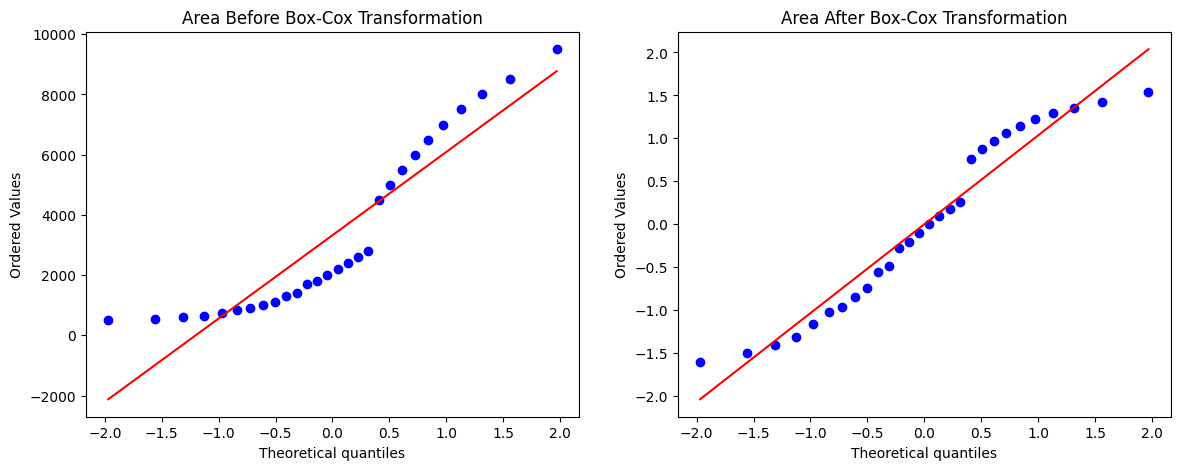

In [122]:
fig,ax=plt.subplots(1,2,figsize=(14,5))

stats.probplot(x_train["Area"],dist="norm",plot=ax[0])
ax[0].set_title('Area Before Box-Cox Transformation')

stats.probplot(x_train_house_df["Area"],dist="norm",plot=ax[1])
ax[1].set_title('Area After Box-Cox Transformation')

2]Yeo-Johnson transformer

In [3]:
import pandas as pd

df = pd.DataFrame({

    "ProfitLoss":[
        -100,-80,-60,-50,-40,-30,-20,-10,-5,0,
        5,10,15,20,25,30,40,50,60,70,
        80,100,120,140,160,180,200,250,300,350,
        400,450,500,600,700,800,900,1000,1200,1500
    ],

    "Debt":[
        -50,-40,-35,-30,-25,-20,-15,-10,-5,0,
        5,10,12,15,18,20,25,30,35,40,
        45,50,60,70,80,90,100,120,140,160,
        180,200,220,250,300,350,400,500,700,900
    ],

    "Investment":[
        0,1,2,3,4,5,6,7,8,9,
        10,12,14,16,18,20,25,30,35,40,
        45,50,60,70,80,90,100,120,140,160,
        180,200,250,300,350,400,500,700,900,1200
    ],

    "Experience":[
        1,1,2,2,3,3,4,4,5,5,
        6,6,7,7,8,8,9,9,10,10,
        11,11,12,12,13,13,14,14,15,15,
        16,16,17,18,19,20,21,22,23,25
    ],

    "Salary":[
        10000,12000,14000,15000,17000,19000,21000,23000,25000,27000,
        30000,33000,36000,40000,45000,50000,55000,60000,68000,75000,
        82000,90000,100000,110000,120000,135000,150000,170000,200000,230000,
        260000,300000,350000,420000,500000,650000,800000,1000000,1300000,1600000
    ]
})

df.to_csv("salary_data.csv",index=False)


In [5]:
df.head()

,ProfitLoss,Debt,Investment,Experience,Salary
0,-100,-50,0,1,10000
1,-80,-40,1,1,12000
2,-60,-35,2,2,14000
3,-50,-30,3,2,15000
4,-40,-25,4,3,17000


In [7]:
df.isnull().sum()

ProfitLoss    0
Debt          0
Investment    0
Experience    0
Salary        0
dtype: int64

In [10]:
df.skew()

ProfitLoss    1.731740
Debt          2.287236
Investment    2.631534
Experience    0.325246
Salary        2.466642
dtype: float64

In [12]:
from sklearn.model_selection import train_test_split

In [14]:
x=df.drop(columns=["Salary"])
y=df[["Salary"]]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [16]:
x_train

,ProfitLoss,Debt,Investment,Experience
13,20,15,16,7
31,450,200,200,16
34,700,300,350,19
8,-5,-5,8,5
17,50,30,30,9
24,160,80,80,13
0,-100,-50,0,1
33,600,250,300,18
5,-30,-20,5,3
11,10,10,12,6


In [18]:
x_train.shape

(28, 4)

In [20]:
y_train.shape

(28, 1)

In [22]:
x_test.shape

(12, 4)

In [24]:
y_test.shape

(12, 1)

In [26]:
from sklearn.preprocessing import PowerTransformer

In [28]:
pt=PowerTransformer(method="yeo-johnson") #by default method is yeo-johnson and it can handle both positive and negative values

In [30]:
x_train_yeo=pt.fit_transform(x_train)
x_test_yeo=pt.transform(x_test)

In [32]:
x_train_yeo

array([[-3.90759016e-01, -3.22738746e-01, -5.45768941e-01,
        -5.01143199e-01],
       [ 7.51787410e-01,  6.95446516e-01,  8.75846917e-01,
         8.23332199e-01],
       [ 1.27915600e+00,  1.12942001e+00,  1.23246015e+00,
         1.20619543e+00],
       [-5.37873414e-01, -5.70902123e-01, -8.73396871e-01,
        -8.56191856e-01],
       [-2.79224096e-01, -2.10698692e-01, -2.22472285e-01,
        -1.75251317e-01],
       [ 5.09506352e-02,  9.72516823e-02,  3.23736430e-01,
         4.16751219e-01],
       [-2.11236360e+00, -2.01240512e+00, -1.89849326e+00,
        -1.73107871e+00],
       [ 1.07372000e+00,  9.17396362e-01,  1.13275020e+00,
         1.08088464e+00],
       [-8.76932890e-01, -9.81285953e-01, -1.07472072e+00,
        -1.25467567e+00],
       [-4.34420243e-01, -3.64976190e-01, -6.85760542e-01,
        -6.74358695e-01],
       [-1.73269141e+00, -1.64712534e+00, -1.59211189e+00,
        -1.73107871e+00],
       [ 5.25094082e-01,  5.08667632e-01,  7.37760153e-01,
      

In [40]:
x_train_yeo_df=pd.DataFrame(x_train_yeo,columns=x_train.columns)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [35]:
lr=LinearRegression()
lr2=LinearRegression()

lr.fit(x_train,y_train)
lr2.fit(x_train_yeo,y_train)

y_pred_lr=lr.predict(x_test)
y_pred_lr2=lr2.predict(x_test_yeo)

print("R2 Score of Linear Regression without Power Transformation:",r2_score(y_test,y_pred_lr))
print("R2 Score of Linear Regression with Power Transformation:",r2_score(y_test,y_pred_lr2))

R2 Score of Linear Regression without Power Transformation: 0.9921148408264219
R2 Score of Linear Regression with Power Transformation: 0.9506466867334677


In [37]:
x_train.skew()

ProfitLoss    1.343959
Debt          1.883371
Investment    2.379529
Experience    0.093636
dtype: float64

In [39]:
from matplotlib import pyplot as plt
from scipy import stats

Text(0.5, 1.0, 'ProfitLoss After Power Transformation')

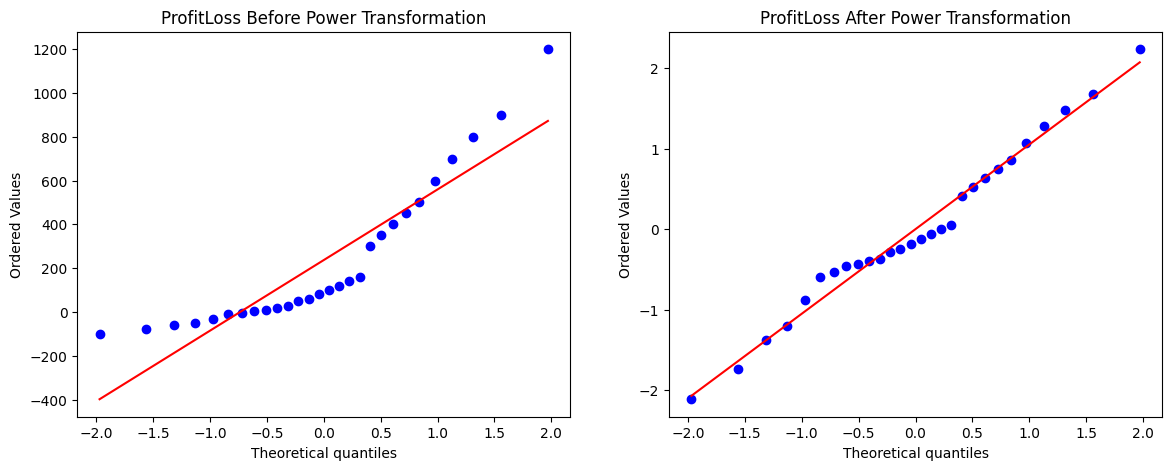

In [41]:
fig,ax=plt.subplots(1,2,figsize=(14,5))

stats.probplot(x_train["ProfitLoss"],dist="norm",plot=ax[0])
ax[0].set_title("ProfitLoss Before Power Transformation") 

stats.probplot(x_train_yeo_df["ProfitLoss"],dist="norm",plot=ax[1])
ax[1].set_title("ProfitLoss After Power Transformation")


In [44]:
x_train.head()

,ProfitLoss,Debt,Investment,Experience
13,20,15,16,7
31,450,200,200,16
34,700,300,350,19
8,-5,-5,8,5
17,50,30,30,9


Text(0.5, 1.0, 'ProfitLoss After Power Transformation')

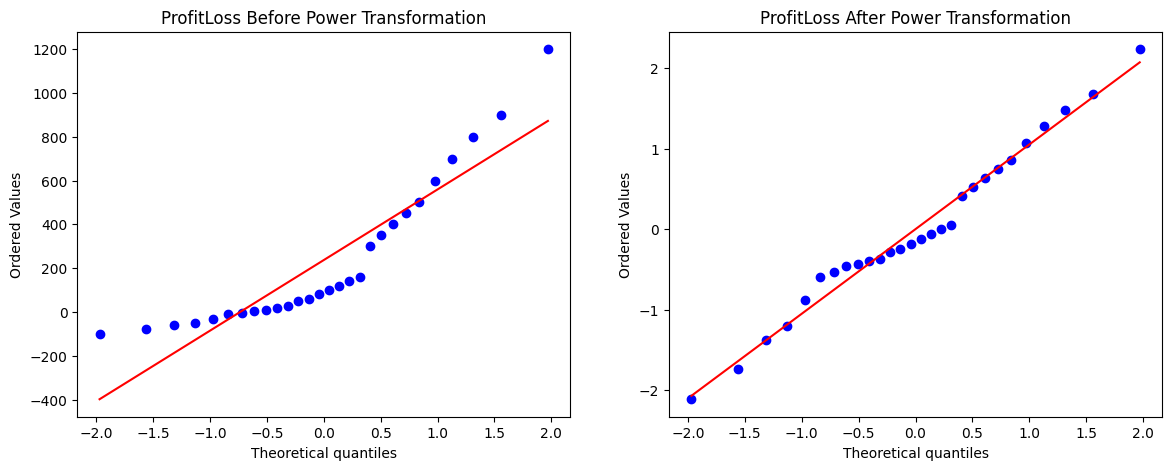

In [53]:
fig,ax=plt.subplots(1,2,figsize=(14,5))

stats.probplot(x_train["ProfitLoss"],dist="norm",plot=ax[0])
ax[0].set_title("ProfitLoss Before Power Transformation")

stats.probplot(x_train_ProfitLoss_df["ProfitLoss"],dist="norm",plot=ax[1])
ax[1].set_title("ProfitLoss After Power Transformation")

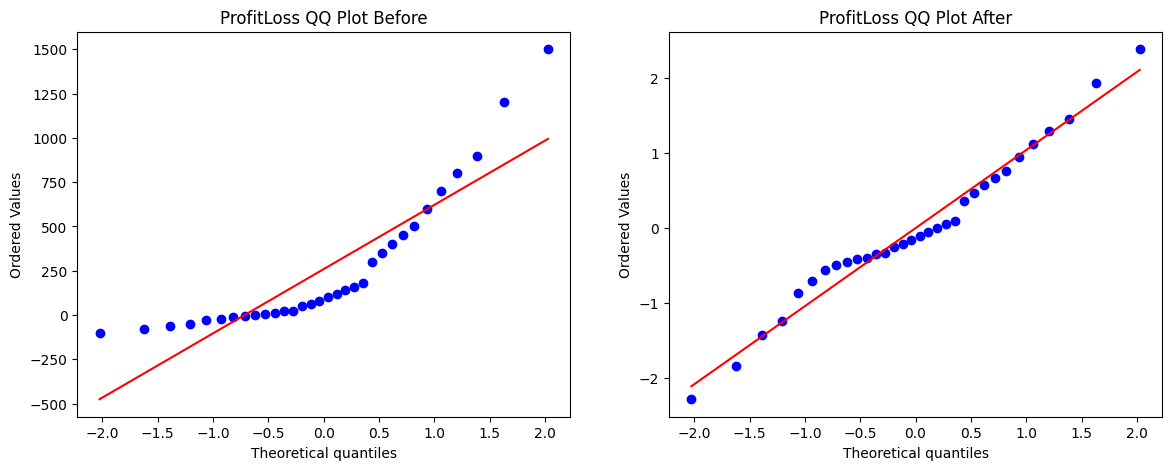

Without Yeo-Johnson: 0.980700512826065
With Yeo-Johnson: 0.7941880121599408


c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import scipy.stats as stats
import matplotlib.pyplot as plt

# X and y
x = df[["ProfitLoss"]]
y = df["Salary"]

# train test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# QQ plot BEFORE transformation
fig, ax = plt.subplots(
    1,2,
    figsize=(14,5)
)

stats.probplot(
    x_train["ProfitLoss"],
    dist="norm",
    plot=ax[0]
)
ax[0].set_title(
    "ProfitLoss QQ Plot Before"
)

# Yeo-Johnson transformation
pt = PowerTransformer(
    method="yeo-johnson"
)

x_train_pt = pt.fit_transform(
    x_train[["ProfitLoss"]]
)

x_test_pt = pt.transform(
    x_test[["ProfitLoss"]]
)

# convert to dataframe
x_train_pt = pd.DataFrame(
    x_train_pt,
    columns=["ProfitLoss_yj"]
)

# QQ plot AFTER transformation
stats.probplot(
    x_train_pt["ProfitLoss_yj"],
    dist="norm",
    plot=ax[1]
)

ax[1].set_title(
    "ProfitLoss QQ Plot After"
)

plt.show()

# --------------------------
# Linear Regression
# --------------------------

lr = LinearRegression()
lr2 = LinearRegression()

# without transform
lr.fit(x_train, y_train)

# with transform
lr2.fit(x_train_pt, y_train)

# prediction
y_pred = lr.predict(x_test)

y_pred2 = lr2.predict(x_test_pt)

# R2 score
print(
    "Without Yeo-Johnson:",
    r2_score(y_test, y_pred)
)

print(
    "With Yeo-Johnson:",
    r2_score(y_test, y_pred2)
)

In [63]:
x = df[["ProfitLoss"]]
y = df["Salary"]

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# only ProfitLoss feature
x = df[["ProfitLoss"]]

# output
y = df["Salary"]

# split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Yeo-Johnson transform
pt = PowerTransformer(
    method="yeo-johnson"
)

x_train_pt = pt.fit_transform(
    x_train[["ProfitLoss"]]
)

x_test_pt = pt.transform(
    x_test[["ProfitLoss"]]
)

# models
lr = LinearRegression()
lr2 = LinearRegression()

# without transform
lr.fit(x_train, y_train)

# with transform
lr2.fit(x_train_pt, y_train)

# prediction
y_pred = lr.predict(x_test)
y_pred2 = lr2.predict(x_test_pt)

# R2 score
print(
    "R2 only ProfitLoss without transform:",
    r2_score(y_test, y_pred)
)

print(
    "R2 only ProfitLoss with Yeo-Johnson:",
    r2_score(y_test, y_pred2)
)

R2 only ProfitLoss without transform: 0.980700512826065
R2 only ProfitLoss with Yeo-Johnson: 0.7941880121599408
